# Week 6: AI-Assisted Insights & Storytelling

**Project:** StaySense BI – AI-Powered Guest Sentiment Intelligence for Homestays

**Dataset:** NYC Airbnb 2019 (Cleaned)

## Objective
Use Generative AI to generate business insight prompts, validate them using real data, and build a data-driven business narrative.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Display all columns
pd.set_option("display.max_columns", None)

In [6]:
df = pd.read_csv("../data/processed/airbnb_cleaned.csv")

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,price_category,review_category,availability_category
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,Standard,Low,High Availability
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,Premium,Low,High Availability
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,0.00,1,365,Standard,No Reviews,High Availability
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,Standard,High,Medium Availability
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,Standard,Low,Unavailable


In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 48895
Columns: 19
<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48895 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48895 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review        

## Dataset Context

The cleaned NYC Airbnb dataset contains listing information including location, room type, pricing, availability, and customer reviews.

This dataset was previously used to build the Week 4 Business Intelligence Dashboard in Looker Studio. The same dataset is used here to validate AI-generated business insights.

# AI-Generated Insight Prompts

To simulate AI-assisted business analysis, the following prompt was provided to ChatGPT.

The AI was given only the dataset context and schema, not the complete dataset, following good data privacy practices.

## Prompt Given to ChatGPT

I have a cleaned Airbnb dataset that contains information about property listings in New York City.

The dataset includes attributes such as:

- Borough
- Neighbourhood
- Room Type
- Price
- Minimum Nights
- Number of Reviews
- Reviews per Month
- Availability (365 days)
- Calculated Host Listings Count

The dataset has already been used to build a Business Intelligence dashboard.

Suggest five important business questions that would help Airbnb hosts or property managers make better business decisions based on this data.

## AI-Generated Business Questions

### Question 1
Which borough has the highest average listing price?

### Question 2
Which room type attracts the highest customer engagement based on reviews?

### Question 3
Is there a relationship between listing availability and the number of customer reviews?

### Question 4
Which price category contains the largest number of listings?

### Question 5
Which borough provides the best balance between affordability and guest popularity?

neighbourhood_group
Manhattan        196.875814
Brooklyn         124.383207
Staten Island    114.812332
Queens            99.517649
Bronx             87.496792
Name: price, dtype: float64


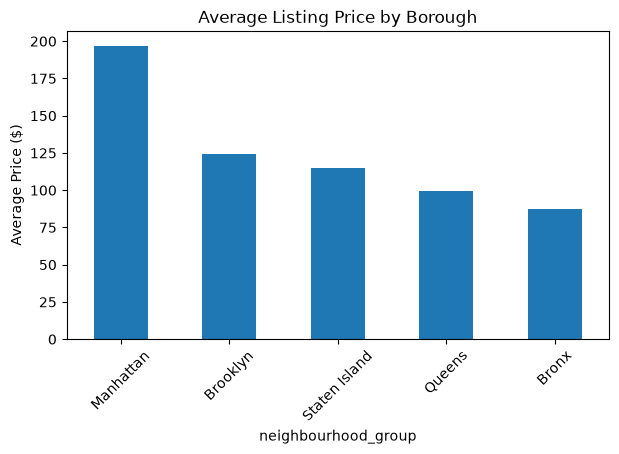

In [8]:
# Question 1
# Average price by borough

avg_price = (
    df.groupby("neighbourhood_group")["price"]
      .mean()
      .sort_values(ascending=False)
)

print(avg_price)

avg_price.plot(kind="bar", figsize=(7,4))
plt.title("Average Listing Price by Borough")
plt.ylabel("Average Price ($)")
plt.xticks(rotation=45)
plt.show()

room_type
Entire home/apt    580403
Private room       538346
Shared room         19256
Name: number_of_reviews, dtype: int64


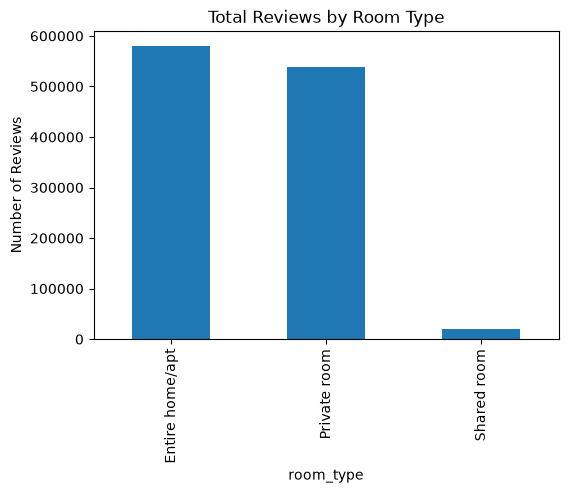

In [9]:
# Question 2
# Reviews by room type

reviews_room = (
    df.groupby("room_type")["number_of_reviews"]
      .sum()
      .sort_values(ascending=False)
)

print(reviews_room)

reviews_room.plot(kind="bar", figsize=(6,4))
plt.title("Total Reviews by Room Type")
plt.ylabel("Number of Reviews")
plt.show()

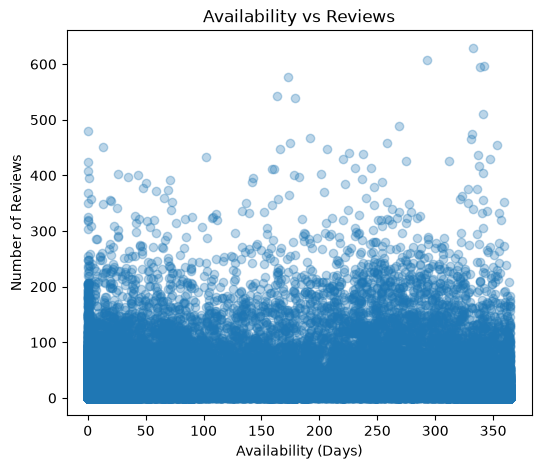

In [10]:
# Question 3
# Availability vs Reviews

plt.figure(figsize=(6,5))

plt.scatter(
    df["availability_365"],
    df["number_of_reviews"],
    alpha=0.3
)

plt.xlabel("Availability (Days)")
plt.ylabel("Number of Reviews")
plt.title("Availability vs Reviews")

plt.show()

Price_Category
Budget      23917
Standard    16583
Premium      7340
Luxury       1044
Name: count, dtype: int64


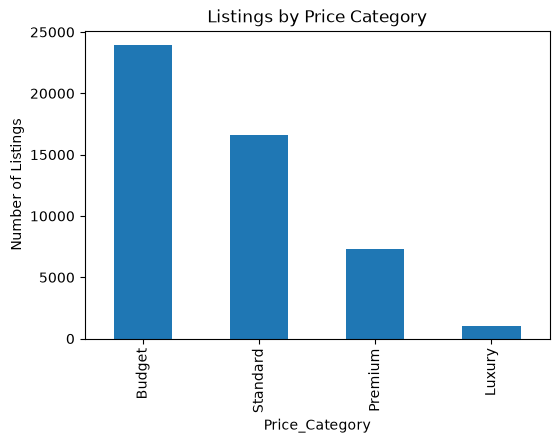

In [11]:
# Question 4
# Price Categories

bins = [0,100,200,500,10000]
labels = ["Budget","Standard","Premium","Luxury"]

df["Price_Category"] = pd.cut(
    df["price"],
    bins=bins,
    labels=labels
)

price_counts = df["Price_Category"].value_counts()

print(price_counts)

price_counts.plot(kind="bar", figsize=(6,4))
plt.title("Listings by Price Category")
plt.ylabel("Number of Listings")
plt.show()

In [13]:
# Question 5
# Average Price & Reviews by Borough

borough_summary = (
    df.groupby("neighbourhood_group")
      .agg({
          "price":"mean",
          "number_of_reviews":"mean"
      })
      .sort_values("price", ascending=False)
)

borough_summary

,price,number_of_reviews
neighbourhood_group,,
Manhattan,196.875814,20.985596
Brooklyn,124.383207,24.202845
Staten Island,114.812332,30.941019
Queens,99.517649,27.700318
Bronx,87.496792,26.004583


# AI Validation

The AI-generated business questions were validated using the actual Airbnb dataset. Each question was assessed based on whether it could be answered accurately using the available data.

In [14]:
validation = pd.DataFrame({
    "AI Question": [
        "Which borough has the highest average listing price?",
        "Which room type attracts the highest customer engagement based on reviews?",
        "Is there a relationship between listing availability and customer reviews?",
        "Which price category contains the largest number of listings?",
        "Which borough provides the best balance between affordability and guest popularity?"
    ],

    "Evaluation": [
        "Accurate",
        "Accurate",
        "Partially Accurate",
        "Accurate",
        "Partially Accurate"
    ],

    "Reason": [
        "Average prices can be calculated directly by borough.",
        "Review counts are available for every room type.",
        "The dataset supports correlation analysis, but the scatter plot shows no strong linear relationship.",
        "Price categories were successfully created and analyzed.",
        "Requires combining multiple metrics and involves business interpretation rather than a direct calculation."
    ]
})

validation

,AI Question,Evaluation,Reason
0,Which borough has the highest average listing ...,Accurate,Average prices can be calculated directly by b...
1,Which room type attracts the highest customer ...,Accurate,Review counts are available for every room type.
2,Is there a relationship between listing availa...,Partially Accurate,"The dataset supports correlation analysis, but..."
3,Which price category contains the largest numb...,Accurate,Price categories were successfully created and...
4,Which borough provides the best balance betwee...,Partially Accurate,Requires combining multiple metrics and involv...


# Business Question 1

## Question

Which borough has the highest revenue potential?

### AI Draft

"Manhattan has the highest average listing price among all boroughs, suggesting stronger revenue potential for property owners. Premium pricing indicates high demand and greater willingness of guests to pay for accommodations in this area."

### Fact Check

**Verified.**

The analysis shows Manhattan has the highest average listing price ($196.88), significantly higher than the other boroughs.

# Business Question 2

## Question

Which accommodation type receives the highest guest engagement?

### AI Draft

"Entire homes and apartments generate the highest guest engagement because they receive the largest number of customer reviews."

### Fact Check

**Verified.**

Entire home/apartment listings accumulated approximately **580,403 reviews**, exceeding Private Rooms (538,346) and Shared Rooms (19,256).

# Business Question 3

## Question

Does increasing listing availability result in more customer reviews?

### AI Draft

"Listings with higher availability generally receive more reviews because guests have more opportunities to book."

### Fact Check

**Partially Verified.**

The scatter plot shows no strong linear relationship between availability and reviews. While some highly available listings receive many reviews, numerous highly available listings receive very few reviews. Availability alone does not explain guest engagement.